[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lanzlagman/intro-python-astro-PUP/blob/main/notebooks/05_traditional_ml_astrophysics.ipynb)

# Notebook 05: Overview of Traditional ML in Astrophysics

**Computational and Data-driven Astrophysics: A Practical Python Workshop**
PUP Physics Society · 15 August 2026

---

Notebook 04 ended with a cluster that every human in the room could see and no line of code
could find. This notebook draws the boundary.

Before we import anything, a piece of history that reframes the whole topic.

> ### Where this all started
>
> Stellar classification was built at Harvard, by hand. **Pickering** and **Fleming** labelled
> spectra A, B, C… by hydrogen line strength; **Maury** rearranged them by line width; **Annie
> Jump Cannon** reordered the sequence to **O B A F G K M** and added decimal subdivisions.
>
> Cannon classified roughly **200,000 spectra between 1911 and 1914**. No computers.
>
> Here is the part that matters for this notebook. Cannon was sorting by the *appearance* of
> hydrogen lines, not by temperature: nobody knew the physical basis yet. The temperature
> ordering **fell out of the data**. It was discovered, not designed.
>
> A decade later **Hertzsprung** and **Russell**, independently, plotted luminosity against
> spectral type and found that stars occupy narrow bands rather than filling the plane.
>
> | What they did | What we would call it now |
> |---|---|
> | Cannon: assign 200,000 spectra to a label set | **supervised classification**, by hand |
> | The temperature ordering emerging unbidden | **structure discovery** |
> | Hertzsprung & Russell: find bands in a scatter plot | **unsupervised learning** |
> | The H–R diagram itself | a **2-D projection** of a high-dimensional space |
>
> **Machine learning is not being imported into astronomy.** Astronomy has been doing this
> since 1901. What changed is the catalogue size: Cannon had 200,000 objects and three years.
> Gaia has 1.8 billion.

## Part 0: Setup and data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error

import os
import pandas as pd

RAW = "https://raw.githubusercontent.com/lanzlagman/intro-python-astro-PUP/main/data/"


def load_workshop_data(filename):
    """Local file first, then GitHub. Works identically in Colab and locally."""
    for path in (f"data/{filename}", f"../data/{filename}"):
        if os.path.exists(path):
            print(f"loaded from disk: {path}")
            return pd.read_csv(path)
    print(f"downloading {filename} from GitHub")
    return pd.read_csv(RAW + filename)


import os
if os.path.exists("data/pleiades_query_result.csv"):
    stars = pd.read_csv("data/pleiades_query_result.csv")
else:
    stars = load_workshop_data("gaia_pleiades.csv")
    stars = stars[(stars["parallax_over_error"] > 5) & (stars["ruwe"] < 1.4)].copy()

stars = stars.dropna(subset=["ra", "dec", "parallax", "pmra", "pmdec", "bp_rp"]).copy()
stars["M_G"] = stars["phot_g_mean_mag"] - 5 * np.log10(1000 / stars["parallax"]) + 5

published = load_workshop_data("pleiades_members_published.csv")
published_ids = set(published["source_id"])

print(f"{len(stars)} stars in the field")
print(f"{len(published_ids)} stars in the published membership list (our ground truth)")

loaded from disk: ../data/gaia_pleiades.csv
loaded from disk: ../data/pleiades_members_published.csv
6911 stars in the field
541 stars in the published membership list (our ground truth)


---
## Part 1: Unsupervised: finding the cluster nobody labelled

The argument is physical, not statistical. Cluster members formed **together**, from **one** cloud, at **one** time. So they share a position on the sky, a distance, and a velocity. Field stars share none of these. That gives us five natural features: `ra`, `dec`, `parallax`, `pmra`, `pmdec`.

Note what is **absent**: brightness and colour. We deliberately do *not* use them. If we find the cluster using only astrometry, the colour–magnitude diagram of the members is an **independent prediction** we can check. Using colour to find the cluster and then celebrating that the members form a main sequence would be circular reasoning.

That restraint: hold something back so you have something to test against, is the difference between a result and a demo.

### Scaling comes first, and it is not optional

Our features have wildly different ranges: `ra` spans ~2 degrees, `pmdec` spans ~60 mas/yr.
Any distance-based algorithm would let the widest-ranging column dominate purely because of
its units. `StandardScaler` converts each column to zero mean and unit variance so that
"close" means "close in physics", not "close in whichever unit somebody picked".

In [3]:
FEATURES = ["ra", "dec", "parallax", "pmra", "pmdec"]

X = stars[FEATURES].to_numpy()
X_scaled = StandardScaler().fit_transform(X)

print("before scaling (per-column standard deviation):")
for name, s in zip(FEATURES, X.std(axis=0)):
    print(f"   {name:10s} {s:8.3f}")
print("\nafter scaling: every column has std = 1.000")

before scaling (per-column standard deviation):
   ra            0.535
   dec           0.494
   parallax      2.270
   pmra          8.945
   pmdec        13.890

after scaling: every column has std = 1.000


### DBSCAN

**DBSCAN** = *Density-Based Spatial Clustering of Applications with Noise*. It suits this
problem better than k-means for three reasons:

1. You do **not** tell it how many clusters to find.
2. It has an explicit **noise** label; field stars are not forced into a group.
3. It finds clusters of any shape, not just spheres.

Two parameters: `eps` (how close counts as neighbouring, in scaled units) and
`min_samples` (how many neighbours make a dense region).

In [4]:
db = DBSCAN(eps=0.30, min_samples=12).fit(X_scaled)
stars["label"] = db.labels_

n_clusters = len({l for l in db.labels_ if l >= 0})
n_noise = int((db.labels_ == -1).sum())

print(f"clusters found : {n_clusters}")
print(f"labelled noise : {n_noise}  ({100*n_noise/len(stars):.1f}% of the field)")

for lab in sorted(l for l in set(db.labels_) if l >= 0):
    g = stars[stars["label"] == lab]
    print(f"\ncluster {lab}: {len(g)} stars")
    print(f"   parallax  {g['parallax'].median():6.2f} mas  ->  "
          f"d = {1000/g['parallax'].median():.0f} pc")
    print(f"   pmra      {g['pmra'].median():6.2f} mas/yr")
    print(f"   pmdec     {g['pmdec'].median():6.2f} mas/yr")

clusters found : 1
labelled noise : 6421  (92.9% of the field)

cluster 0: 490 stars
   parallax    7.35 mas  ->  d = 136 pc
   pmra       19.87 mas/yr
   pmdec     -45.50 mas/yr


> **The textbook distance to the Pleiades is 130 pc.** We never told the algorithm where the
> cluster was, how far away it was, or that there was one. We handed it five columns of numbers
> and it returned a distance that matches.

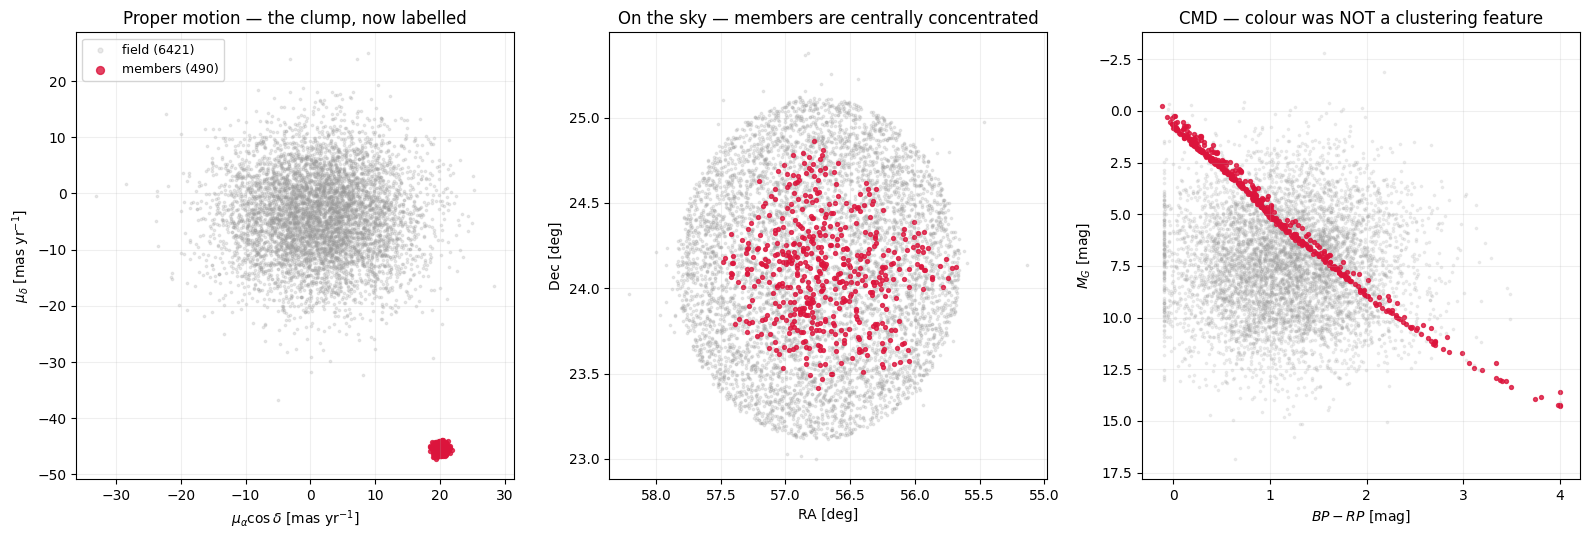

In [5]:
members = stars[stars["label"] >= 0]
field = stars[stars["label"] == -1]

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# --- proper motion: the diagram from NB04, now with a boundary drawn
axes[0].scatter(field["pmra"], field["pmdec"], s=3, alpha=0.2,
                color="0.6", label=f"field ({len(field)})")
axes[0].scatter(members["pmra"], members["pmdec"], s=8, alpha=0.8,
                color="crimson", label=f"members ({len(members)})")
axes[0].set_xlabel(r"$\mu_\alpha\cos\delta$ [mas yr$^{-1}$]")
axes[0].set_ylabel(r"$\mu_\delta$ [mas yr$^{-1}$]")
axes[0].set_title("Proper motion: the clump, now labelled")
axes[0].legend(markerscale=2, fontsize=9)

# --- sky positions
axes[1].scatter(field["ra"], field["dec"], s=3, alpha=0.2, color="0.6")
axes[1].scatter(members["ra"], members["dec"], s=8, alpha=0.8, color="crimson")
axes[1].set_xlabel("RA [deg]"); axes[1].set_ylabel("Dec [deg]")
axes[1].set_title("On the sky: members are centrally concentrated")
axes[1].invert_xaxis()

# --- the independent check: a CMD we never used to cluster
axes[2].scatter(field["bp_rp"], field["M_G"], s=3, alpha=0.15, color="0.6")
axes[2].scatter(members["bp_rp"], members["M_G"], s=8, alpha=0.8, color="crimson")
axes[2].invert_yaxis()
axes[2].set_xlabel("$BP - RP$ [mag]"); axes[2].set_ylabel("$M_G$ [mag]")
axes[2].set_title("CMD: colour was NOT a clustering feature")

for a in axes:
    a.grid(alpha=0.2)
plt.tight_layout(); plt.show()

> **The third panel is the real result.** We clustered on position, distance and motion only.
> Colour and magnitude were withheld. Yet the members trace a clean, narrow main sequence while
> the field stars scatter.
>
> Nothing forced that. One cloud, one time, one distance, so differences are due to mass alone;
> a physical claim, confirmed by an algorithm that was never told any stellar physics.
>
> This is what a *prediction* looks like, as opposed to a *fit*.

---
## Part 2: Validation: numbers, not vibes

A cluster that looks right is not a result. Score it against the published membership list we pulled from VizieR in Notebook 02.

- **Purity** (precision): of the stars we called members, what fraction really are?
- **Completeness** (recall): of the real members, what fraction did we find?

These trade off against each other. Loosening `eps` raises completeness and lowers purity. Which one you should favour depends entirely on what you plan to do next; and saying so out loud is part of the analysis.

In [6]:
def score(member_ids, truth_ids):
    member_ids, truth_ids = set(member_ids), set(truth_ids)
    tp = len(member_ids & truth_ids)
    purity = tp / len(member_ids) if member_ids else 0.0
    completeness = tp / len(truth_ids) if truth_ids else 0.0
    f1 = 2 * purity * completeness / (purity + completeness) if tp else 0.0
    return purity, completeness, f1


p, c, f1 = score(members["source_id"], published_ids)
print(f"recovered members : {len(members)}")
print(f"published members : {len(published_ids)}")
print()
print(f"purity       {p:.3f}   ({p*100:.0f}% of our members appear in the published list)")
print(f"completeness {c:.3f}   ({c*100:.0f}% of published members were recovered)")
print(f"F1           {f1:.3f}")

recovered members : 490
published members : 541

purity       0.859   (86% of our members appear in the published list)
completeness 0.778   (78% of published members were recovered)
F1           0.817


### ✏️ YOUR TURN

`eps` controls how greedy DBSCAN is. Try a few values and watch purity and completeness
move in opposite directions.

In [7]:
# YOUR TURN: add a couple of your own values to this list
eps_values = [0.15, 0.20, 0.25, 0.30, 0.35]      # <-- extend me

print(f"{'eps':>6} {'members':>9} {'purity':>8} {'complete':>9} {'F1':>7}")
print("-" * 43)
results = []
for eps in eps_values:
    lab = DBSCAN(eps=eps, min_samples=12).fit_predict(X_scaled)
    ids = stars.loc[lab >= 0, "source_id"]
    p_, c_, f_ = score(ids, published_ids)
    results.append((eps, len(ids), p_, c_, f_))
    print(f"{eps:6.2f} {len(ids):9d} {p_:8.3f} {c_:9.3f} {f_:7.3f}")

best = max(results, key=lambda r: r[4])
print(f"\nbest F1 at eps = {best[0]}")
print("Notice: no single eps maximises both purity and completeness.")
print("There is no 'correct' setting - only a choice you have to justify.")

   eps   members   purity  complete      F1
-------------------------------------------
  0.15         0    0.000     0.000   0.000
  0.20       135    0.867     0.216   0.346
  0.25       352    0.849     0.553   0.670
  0.30       490    0.859     0.778   0.817
  0.35       542    0.838     0.839   0.838

best F1 at eps = 0.35
Notice: no single eps maximises both purity and completeness.
There is no 'correct' setting - only a choice you have to justify.


---
## Part 3: Supervised: fitting the main sequence

**Main-sequence fitting**: if you know what the main sequence looks like in **absolute** magnitude, and you observe a cluster's sequence in **apparent** magnitude, the vertical offset between them is the distance modulus, and therefore the distance.

That procedure needs a **model of the main sequence**. Historically it was drawn by hand through a calibration cluster. Here we fit one, which is supervised learning: known inputs (colour), known outputs (absolute magnitude), learn the mapping.

In [8]:
# Use only cluster members - they share a distance, which is the whole point
ms = members[(members["bp_rp"] > 0.0) & (members["bp_rp"] < 2.5)].dropna(
    subset=["bp_rp", "M_G"])

X_ms = ms[["bp_rp"]].to_numpy()
y_ms = ms["M_G"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X_ms, y_ms, test_size=0.3, random_state=42)

print(f"train on {len(X_train)} members, test on {len(X_test)} held out")

# A straight line first - always start with the simplest thing that could work
linear = LinearRegression().fit(X_train, y_train)
mae_lin = mean_absolute_error(y_test, linear.predict(X_test))

# Then a cubic, because the main sequence is visibly curved
coef = np.polyfit(X_train.ravel(), y_train, 3)
mae_cubic = mean_absolute_error(y_test, np.polyval(coef, X_test.ravel()))

print(f"\nlinear  test MAE = {mae_lin:.3f} mag")
print(f"cubic   test MAE = {mae_cubic:.3f} mag")
print(f"improvement: {100*(mae_lin-mae_cubic)/mae_lin:.0f}%")

train on 317 members, test on 136 held out

linear  test MAE = 0.178 mag
cubic   test MAE = 0.165 mag
improvement: 7%


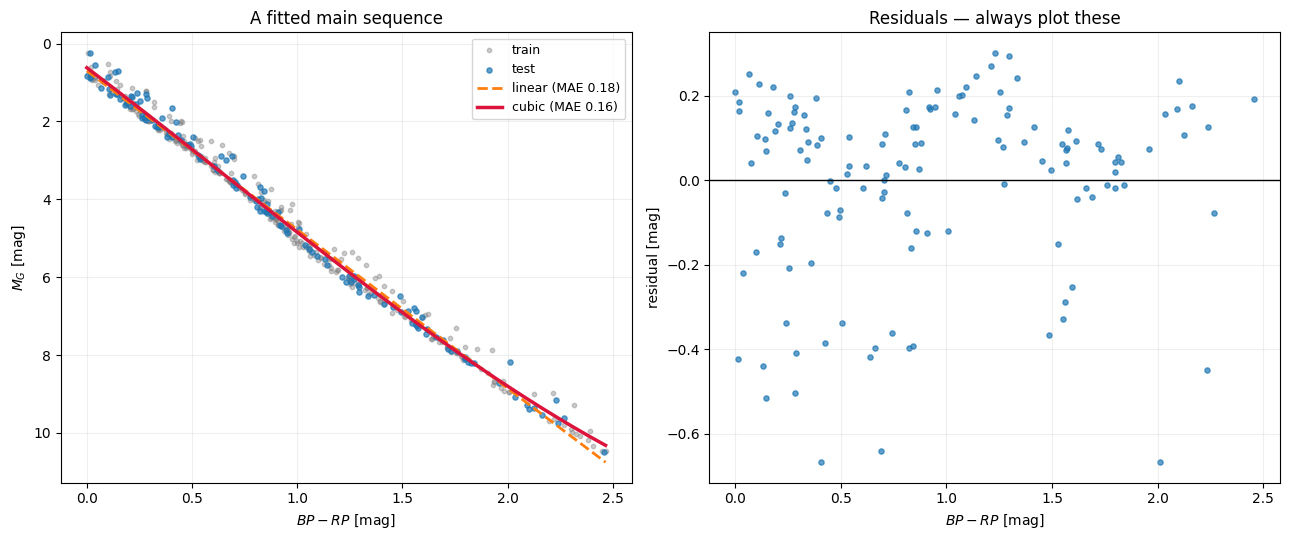

residual scatter (std) = 0.215 mag

Asymmetry here is physical, not a modelling failure: unresolved binary
systems sit up to 0.75 mag ABOVE the single-star sequence, because two
stars at one distance look like one brighter star.


In [9]:
grid = np.linspace(X_ms.min(), X_ms.max(), 200)
resid = y_test - np.polyval(coef, X_test.ravel())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

ax1.scatter(X_train, y_train, s=10, alpha=0.4, color="0.5", label="train")
ax1.scatter(X_test, y_test, s=14, alpha=0.7, color="tab:blue", label="test")
ax1.plot(grid, linear.predict(grid.reshape(-1, 1)), "--", color="tab:orange",
         lw=2, label=f"linear (MAE {mae_lin:.2f})")
ax1.plot(grid, np.polyval(coef, grid), color="crimson", lw=2.5,
         label=f"cubic (MAE {mae_cubic:.2f})")
ax1.invert_yaxis()
ax1.set_xlabel("$BP - RP$ [mag]"); ax1.set_ylabel("$M_G$ [mag]")
ax1.set_title("A fitted main sequence")
ax1.legend(fontsize=9); ax1.grid(alpha=0.2)

ax2.scatter(X_test.ravel(), resid, s=14, alpha=0.7, color="tab:blue")
ax2.axhline(0, color="k", lw=1)
ax2.set_xlabel("$BP - RP$ [mag]"); ax2.set_ylabel("residual [mag]")
ax2.set_title("Residuals")
ax2.grid(alpha=0.2)

plt.tight_layout(); plt.show()

print(f"residual scatter (std) = {resid.std():.3f} mag")
print("\nAsymmetry here is physical, not a modelling failure: unresolved binary")
print("systems sit up to 0.75 mag ABOVE the single-star sequence, because two")
print("stars at one distance look like one brighter star.")

---
## Part 4: Dimensionality reduction: what the H–R diagram really is

Hertzsprung and Russell had many measurable quantities available and chose **two** axes. The
result was arguably the most important diagram in astrophysics.

Modern framing: they performed a **dimensionality reduction by hand**, and happened to pick a
projection in which the structure was visible. **PCA** does that search automatically.

In [10]:
phot = ["phot_g_mean_mag", "phot_bp_mean_mag", "phot_rp_mean_mag", "bp_rp"]
sub = stars.dropna(subset=phot)

Z = StandardScaler().fit_transform(sub[phot])
pca = PCA(n_components=4).fit(Z)

print("variance explained by each component:")
for i, v in enumerate(pca.explained_variance_ratio_, 1):
    print(f"   PC{i}: {v:6.1%}   (cumulative {pca.explained_variance_ratio_[:i].sum():6.1%})")

print("\nPC1 loadings:")
for name, w in zip(phot, pca.components_[0]):
    print(f"   {name:22s} {w:+.3f}")
print("\nPC1 weights all three magnitudes together: it is essentially 'brightness'.")
print("PC2 sets them against each other: it is essentially 'colour', i.e. temperature.")
print("PCA rediscovered the two axes of the H-R diagram, from four columns of numbers.")

variance explained by each component:
   PC1:  75.7%   (cumulative  75.7%)
   PC2:  24.3%   (cumulative 100.0%)
   PC3:   0.0%   (cumulative 100.0%)
   PC4:   0.0%   (cumulative 100.0%)

PC1 loadings:
   phot_g_mean_mag        -0.572
   phot_bp_mean_mag       -0.575
   phot_rp_mean_mag       -0.562
   bp_rp                  -0.164

PC1 weights all three magnitudes together: it is essentially 'brightness'.
PC2 sets them against each other: it is essentially 'colour', i.e. temperature.
PCA rediscovered the two axes of the H-R diagram, from four columns of numbers.


> ### Read PC3 and PC4: exactly 0.0%
>
> Not a rounding artefact. `bp_rp` is **defined** as `phot_bp_mean_mag - phot_rp_mean_mag`, so
> it carries no information the other columns do not already contain.
>
> Four columns describe a space that is genuinely only **two-dimensional**, and PCA found that
> without being told. A brightness and a colour are all the independent information there is.
>
> **Which is precisely why the H–R diagram has two axes.** Two is the real dimensionality of
> stellar photometry, and Hertzsprung and Russell found it by eye in 1911.
>
> A component with zero variance is also a useful diagnostic in your own work: it means you fed
> the model a column that is a deterministic function of other columns.

---
## Part 5: Three things generic ML tutorials get wrong about astronomy

**1. Every measurement has its own uncertainty.** Our table carries `parallax_error`, `pmra_error`, `pmdec_error`; and we ignored all of them. A bright star's parallax can be a hundred times better measured than a faint one's. Weighted or fully probabilistic methods exist for exactly this reason, and are usually the correct choice.

**2. Your sample has a selection function.** We cut at $G < 18$ and `parallax_over_error > 5`. Those cuts preferentially remove faint, distant, red stars. The catalogue is not the universe; it is the universe seen through an instrument with known biases, and a model trained on the catalogue learns the instrument too.

**3. Your labels are model-derived, not ground truth.** Our "published membership list" was itself produced by somebody else's clustering algorithm, with their own parameter choices. When we report 86% purity we are measuring **agreement with a previous analysis**, not correctness. Cannon's OBAFGKM labels had the same status, and encoded real physics anyway.

> ### Where this is going
>
> Hubble's morphological classification of galaxies: ellipticals, spirals, barred spirals,
> irregulars, is another human-built label set applied by eye, for decades, one galaxy at a
> time.
>
> Surveys now image **billions** of galaxies. Classifying them is an active research problem,
> and it is the subject of my own PhD: reframing galaxy morphological classification as a
> **Visual Question Answering** problem, so that a vision–language model is asked *"does this
> galaxy have a bar?"* rather than being asked to emit a class label.
>
> The line from Cannon at Harvard in 1911 to this is unbroken. Same task, same difficulty, four
> orders of magnitude more data.

---
## What you built, and where it goes

| You wrote | Why it matters |
|---|---|
| Feature scaling before any distance-based method | non-negotiable, and constantly forgotten |
| DBSCAN with an explicit noise class | field stars should not be forced into a group |
| Holding out colour, then checking the CMD | the difference between a prediction and a fit |
| Purity / completeness against an external list | a number you can defend |
| Train/test split and a residual plot | how you find out you are fooling yourself |

**Advanced track A1** goes further: HDBSCAN and Gaussian Mixtures, per-star membership
*probabilities* instead of hard labels, and proper treatment of the measurement errors we
ignored today. **A2** takes the clean member list and fits an isochrone for the cluster's age,
metallicity and reddening.

---
### Sources

Historical and physical background follows Carroll & Ostlie, *An Introduction to Modern Astrophysics*, 2nd ed.: §8.1 (The Formation of Spectral Lines), §8.2 (The Hertzsprung–Russell Diagram), §13.3 (Stellar Clusters), §25.1 (The Hubble Sequence).

### If you want to go deeper
- **Ting (2025), *Statistical Machine Learning for Astronomy:*** arXiv:2506.12230, free, ~677 pages. **The single best next step** if you are heading toward a thesis.
- astroML interactive book · <http://www.astroml.org/astroML-notebooks/>
- scikit-learn user guide, *Clustering* and *Model selection*